# 07 — v2.5 · The product on the contracted run (run spec v3 §1a items 3, 5, 7 + §5)

On `v25_run001`: coverage per complex and per inter-complex link band (existing PAs · IPCAs incremental · the prioritizr core on
allocatable land · outside all three) with the area-expectation row; the accounting (dissolved unions beside per-link sums; branches
as links-with-n reconciled with `branches.csv`); the act check (Bow Valley rule); Layer A / slivers / Layer B tables, T1–T4, the
headline table and the GIS export. Zero solves.

In [1]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/wolverine_refugia_connectivity/, below the repo root where
# config.py and the corridor engine modules sit. Same bootstrap as analyses/northern_connectivity/.
import sys, pathlib, json
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import numpy as np
import pandas as pd
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
for _m in (config, cp, cg, cc):
    importlib.reload(_m)

KEY = "wolverine"
CFG = config.CORRIDORS[KEY]
HERE = ROOT / "analyses" / "wolverine_refugia_connectivity"

import matplotlib.pyplot as plt
import corridors_mapstyle as ms
import corridors_director as cd
import director_core as dc
import wolverine_director as wd
for _m in (ms, cd, dc, wd):
    importlib.reload(_m)

import wolverine_postprocess as wp
importlib.reload(wp)
RUN = CFG["v25"]["run_id"]
P0 = wp.load_run(config.RESULTS_DIR / CFG["results_subdir"] / RUN)

v25_run003: results context loaded (29 edges, 30 branches, corridor 29,619 km²)
v25_run003: 23 complexes, 28 inter-complex links between 28 pairs (0 pairs with more than one link; 1 still near-contiguous -- expected 0 after the second pass) | cutoff 13.6230 = 4.09 km detour


## Coverage (with the expectation row) · Accounting

In [2]:
cov = wp.coverage(P0)
display(cov[cov.kind != "link"].round(3))
acc = wp.accounting(P0)
lk = wp.write_run_product(P0)

prioritizr core (balanced scenario, guarded tier on allocatable land, f >= 0.7 outside locked PAs): 51,580 km² at 1 km -> 51,575 km² on the routable 300 m grid
expectation over the routable frame: PAs 13.0% · +IPCAs 11.0% · core 3.3% (core beyond PAs+IPCAs 3.0%) · outside all three 73.0%
complexes (area-weighted): PAs 35.4% · +IPCAs 8.1% · core 7.5% · outside 49.7%
corridor bands (area-weighted): PAs 12.5% · +IPCAs 10.0% · core 4.2% · outside 73.2% | links crossing land outside PAs + IPCAs: 27 of 28


,kind,id,label,area_km2,pa,ipca_incremental,core,core_incremental,outside_all
0,expectation,0,EXPECTATION: the whole routable Y2Y frame,1551666.6,0.130,0.110,0.033,0.030,0.730
1,complex,1,Refugia complex (Nahanni),20657.2,0.306,0.073,0.022,0.015,0.607
2,complex,2,Refugium (Nahanni),285.6,0.662,0.000,0.000,0.000,0.338
3,complex,3,"Refugium (Boya Lake, W)",292.1,0.000,0.000,0.000,0.000,1.000
4,complex,4,"Refugium (Stikine River, NW)",743.1,0.000,0.485,0.405,0.195,0.320
5,complex,5,"Refugia complex (Stikine River, NW)",856.5,0.014,0.000,0.000,0.000,0.986
6,complex,6,Refugia complex (Northern Rocky Mountains),14859.8,0.360,0.347,0.001,0.001,0.293
7,complex,7,"Refugia complex (Sustut, E)",29569.9,0.174,0.200,0.141,0.123,0.502
8,complex,8,Refugium (Sustut),279.2,0.605,0.000,0.000,0.000,0.395
9,complex,9,Refugium (Omineca),382.2,0.586,0.000,0.000,0.000,0.414


accounting: all bands (v2 corridors.tif) 29,619 km² | the 40 corridor links dissolved 29,440 km² (per-link sum 30,429) | outside PAs + IPCAs 22,603, outside PAs + IPCAs + core 21,511 | branches: {1: 26, 2: 2} -> total 30 vs branches.csv 30 (reconciles)
written -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/postprocess: corridor_links.csv (28), coverage.csv, accounting.json


## The package: the act check (Bow Valley rule), Layer A / slivers / Layer B, T1–T4, the headline, GIS

In [3]:
wd.STYLE.update(wd.V25_STYLE)
R = wp.attach(cc.load_results(config.RESULTS_DIR / CFG["results_subdir"] / RUN))
P = wd.package(R)
bow, straddles = wd.bow_valley_check(P)
display(bow)
note = ""
if straddles:                                                # the rule (run spec v3 §8): move the southern break to the Bow Valley, record it
    wd.STYLE["act_breaks_lat"] = (wd.STYLE["bow_valley_lat"],)
    P = wd.package(R); note = f"southern act break moved to the Bow Valley ({wd.STYLE['bow_valley_lat']} N): the Banff-Yoho links straddled 51 N"
    P.act_note = note; print(note)
(R.run_dir / "postprocess" / "acts.json").write_text(json.dumps(dict(break_moved=bool(straddles), act_breaks_lat=list(wd.STYLE["act_breaks_lat"]),
    note=note, links_near_banff=bow.to_dict("records")), indent=2, default=str))

v25_run003: results context loaded (29 edges, 30 branches, corridor 29,619 km²)
attached (run mode): 23 complexes, 28 inter-complex links, coverage yes
wolverine package: classes -> only viable 1 · last affordable 5 · narrowing 10 · options 13 | geometric classes first (D25/D24): adjacent 0 (barrier between 0), width not assessable 0 | 23 nodes | 3 examples | H8 closed | already connected: 0 within existing PAs, 1 only with the proposed IPCAs (mode 'overlay')
Bow Valley check: 0 corridor link(s) within 60 km of Banff -> one act, no seam issue


""


102

A_complexes: 23 complexes -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/A_complexes.csv
A_slivers: 133 within-complex slivers, 62 with a cost-100/1000 feature (the within-complex pinch points) -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/A_slivers.csv
A_fronts: 133 fronts (84 open, 49 cut) in 8 complexes -> A_fronts.csv, A_fronts_by_complex.csv
B_corridors: 29 corridor links, 28 crossing unprotected land -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/B_corridors.csv


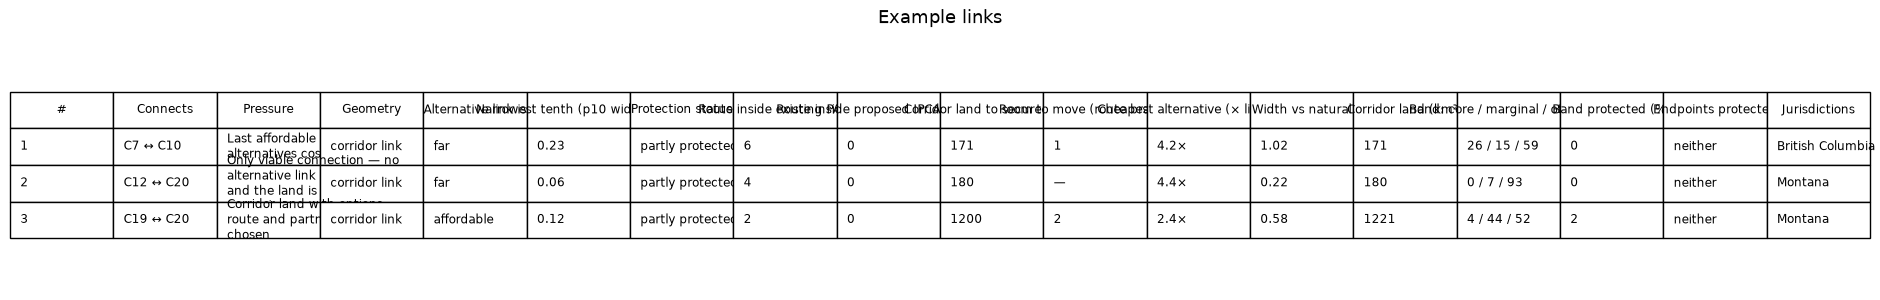

T1_links: 3 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/T1_links.csv


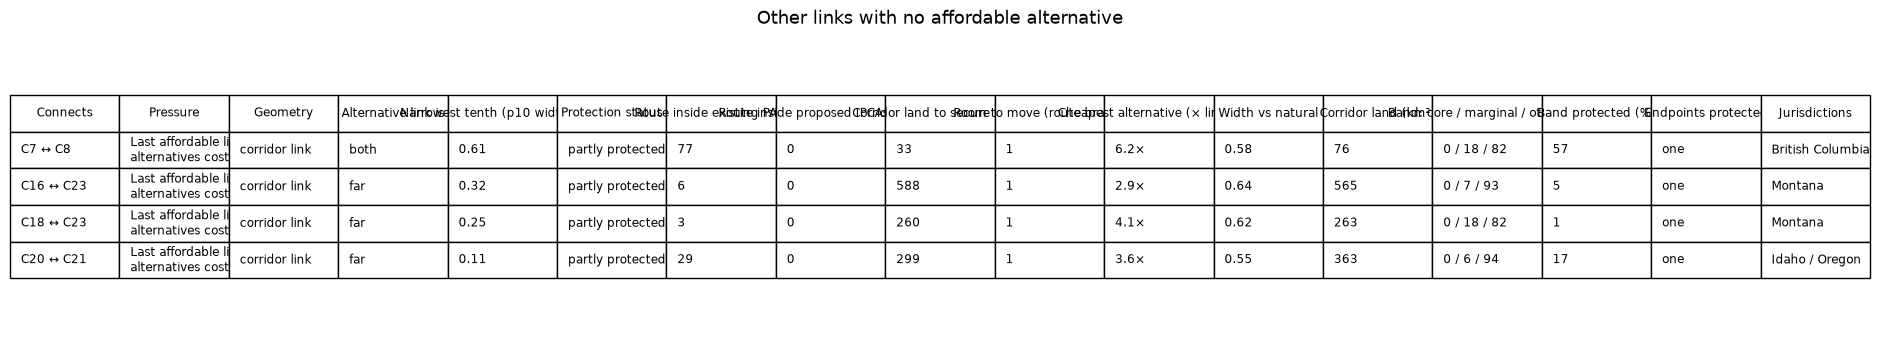

T2_flagged_links: 4 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/T2_flagged_links.csv


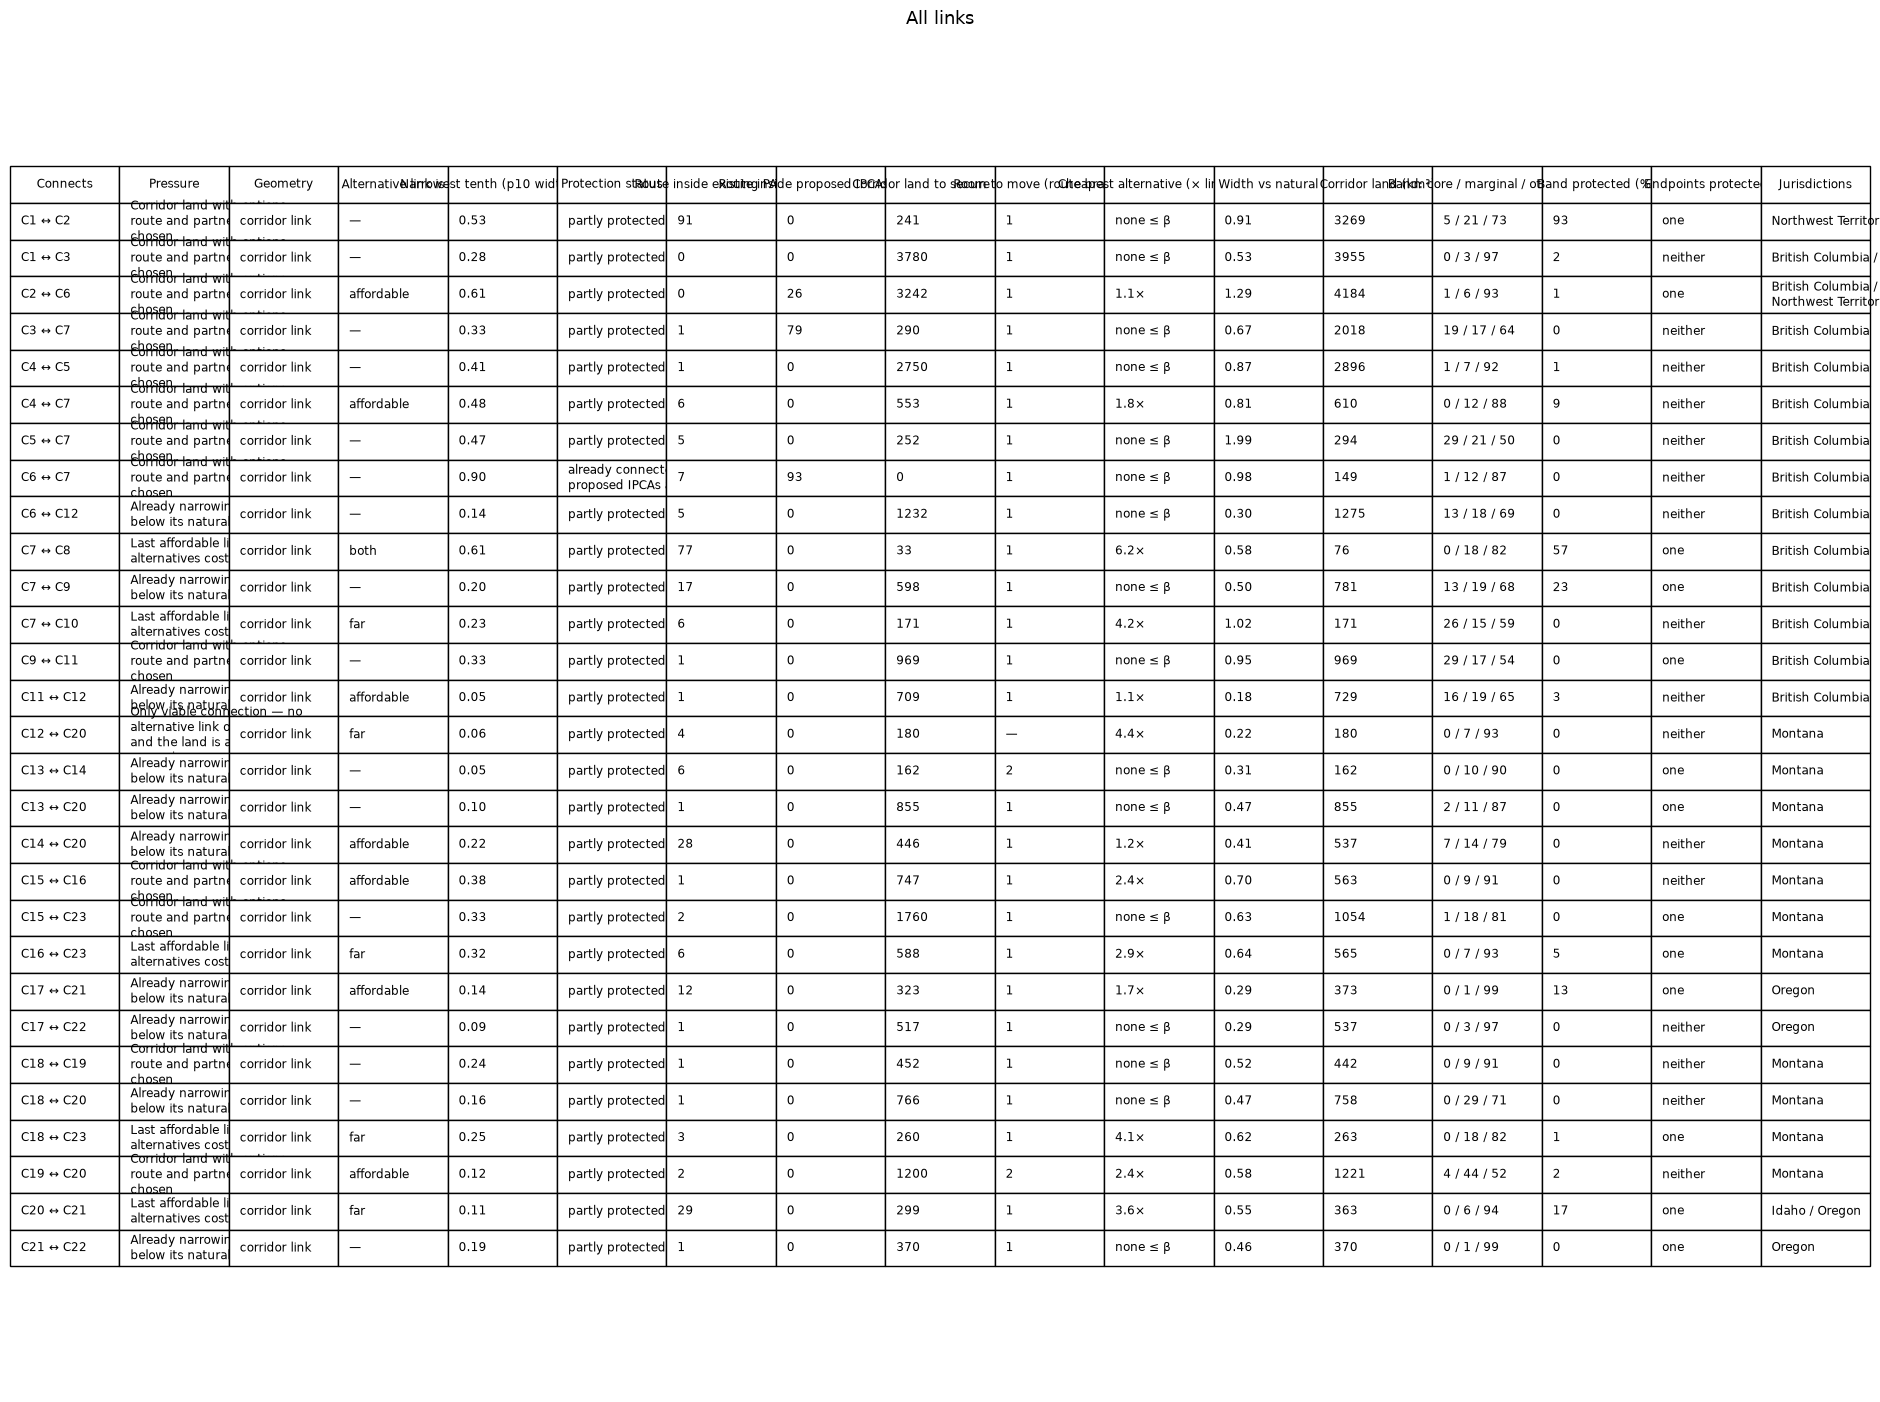

T3_all_links: 29 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/T3_all_links.csv


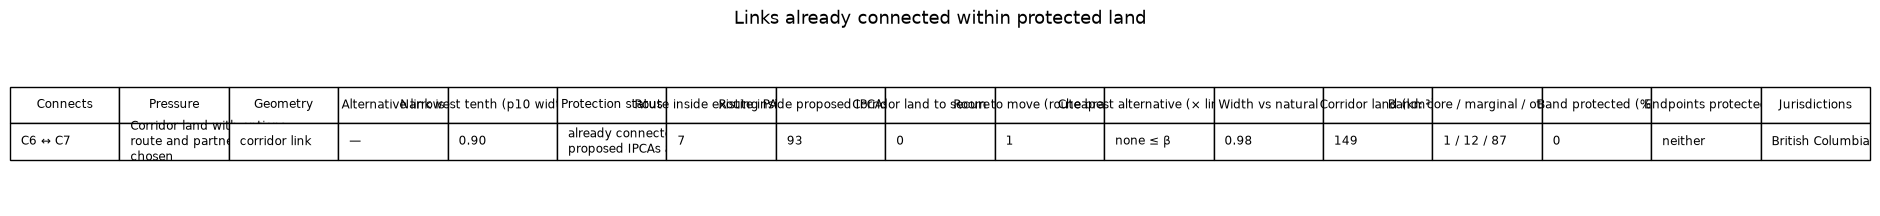

T4_satisfied_links: 1 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v25_run003/director_package/tables/T4_satisfied_links.csv
  act  complexes  complex_area_km2  share_in_pas  share_with_ipcas  share_in_core  corridor_links  narrowing_links  last_affordable_links
north         12            204433         0.302             0.413          0.089              14                3                      2
south         11             78563         0.490             0.494          0.040              15                8                      4
corridor links 29: 28 cross unprotected land (97%) | corridor land dissolved 29440 km², outside PAs+IPCAs 22603, outside PAs+IPCAs+core 21511 | narrowing by act {'north': 3, 'south': 8} | top class empty: False
  last affordable: C7 ↔ C8 (north) p10 0.61, median 0.58, alt both, branches 1
  last affordable: C7 ↔ C10 (north) p10 0.23, median 1.02, alt far, branches 1
  last affordable: C12 ↔ C20 

,complex,fronts,open,cut,narrow,road_on_path,E_patch_level,E_interior_reading,front_land_per_link_sum_km2
complex_id,,,,,,,,,
1,C1,21,20,1,0,1,9,18,2414
5,C5,1,1,0,0,0,0,1,300
6,C6,9,7,2,1,1,1,9,1085
7,C7,59,47,12,4,11,10,30,8410
12,C12,25,1,24,23,22,17,23,1619
13,C13,1,1,0,0,0,1,1,163
20,C20,9,3,6,5,6,2,5,2073
23,C23,8,4,4,3,2,3,4,1302


,edge_id,Connects,Complexes,Class,Alternative link is,"Width ratio, median","Width ratio, tenth percentile",Route branches,"Band land (km², dissolved per link; links overlap)",Outside PAs and IPCAs (km²),Crosses unprotected land,Already connected,Complex i inside PAs (%),Complex j inside PAs (%),Path (km),Act
14,E011_019,C12 ↔ C20,C12 ↔ C20,Only viable connection — no alternative link o...,far,0.22,0.06,NaN,180,180,True,no,33,32,16.8,south
27,E019_020,C20 ↔ C21,C20 ↔ C21,Last affordable link — alternatives cost far more,far,0.55,0.11,1.0,363,299,True,no,32,73,27.9,south
11,E006_009,C7 ↔ C10,C7 ↔ C10,Last affordable link — alternatives cost far more,far,1.02,0.23,1.0,171,171,True,no,17,0,9.9,north
25,E017_022,C18 ↔ C23,C18 ↔ C23,Last affordable link — alternatives cost far more,far,0.62,0.25,1.0,263,260,True,no,0,66,22.5,south
20,E015_022,C16 ↔ C23,C16 ↔ C23,Last affordable link — alternatives cost far more,far,0.64,0.32,1.0,615,588,True,no,0,66,39.6,south
9,E006_007,C7 ↔ C8,C7 ↔ C8,Last affordable link — alternatives cost far more,both,0.58,0.61,1.0,76,33,True,no,17,61,7.8,north
13,E010_011,C11 ↔ C12,C11 ↔ C12,Already narrowing — corridor below its natural...,affordable,0.18,0.05,1.0,729,709,True,no,0,33,92.1,north
15,E012_013,C13 ↔ C14,C13 ↔ C14,Already narrowing — corridor below its natural...,—,0.31,0.05,2.0,162,162,True,no,56,49,10.8,south
22,E016_021,C17 ↔ C22,C17 ↔ C22,Already narrowing — corridor below its natural...,—,0.29,0.09,1.0,537,517,True,no,36,6,64.5,south
16,E012_019,C13 ↔ C20,C13 ↔ C20,Already narrowing — corridor below its natural...,—,0.47,0.10,1.0,855,855,True,no,56,32,61.5,south


In [4]:
tA = wd.table_complexes(P); tS = wd.table_slivers(P); tF, tFc = wd.table_fronts(P); tB = wd.table_corridors(P)
t1 = wd.table_links(P, "examples"); t2 = wd.table_links(P, "flagged"); t3 = wd.table_links(P, "all"); t4 = wd.table_links(P, "satisfied")
hl = wd.headline(P)
wd.export_gis(P); wd.export_complexes_gis(P)
display(tFc)
tB

## Done — `08_director_outputs.ipynb`.